### Imports

In [ ]:
import os
import torch
import pandas as pd
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torch import optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

import sys
sys.path.append('..')

from src.utils.dataloading import ClipDataset, ImageToClip, FeaturesDataset
from src.utils.model import MultitaskLoss, AgeNet
from src.utils.utils import train, extract_features

# Modelling

We build the model in this section. The task is to estimate a person’s age while also detecting whether a person is present in the image or not. We use ``EfficientNet`` as the backbone for feature extraction, followed by a Transformer layer to model temporal information across frames. The network has two output heads: one for binary classification of person presence, and another for age regression.

## Setup

In [2]:
# setup
seed = 42
torch.manual_seed(seed)
# device setup
device = (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
print(f"Training on device {device}.")

Training on device cuda.


## Preprocessing

### reading and splitting
The dataset is divided into training, validation, and test sets using an 80–10–10 split, respectively.

In [3]:
path = "../data/dataset/metadata.csv"
files = pd.read_csv(path)

train_files, test_files = train_test_split(
    files,
    test_size=0.2,
    random_state=seed,
    shuffle=True
)

val_files, test_files = train_test_split(
    test_files,
    test_size=0.5,
    random_state=seed,
    shuffle=True
)

# converting the dataframes to dictionary to avoid pandas syntax
train_files = train_files.to_dict("records")
val_files   = val_files.to_dict("records")
test_files  = test_files.to_dict("records")

### normalizing
For normalization, we can either compute the dataset statistics ourselves, or use the precomputed ``ImageNet`` statistics since we are gonna use ``EfficientNet`` as the backbone model.

In [4]:
# precomputed mean and std
train_mean = torch.tensor([0.485, 0.456, 0.406])
train_std  = torch.tensor([0.229, 0.224, 0.225])

now we compose our augmentation and normalization in one transform

In [5]:
IMG_SIZE = 224
N_FRAMES = 4

base = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=train_mean, std=train_std)
])

augment = T.Compose([
        T.ColorJitter(0.3, 0.3, 0.3, 0.1),
        T.RandomHorizontalFlip(),
        T.RandomGrayscale(p=0.2),
        T.GaussianBlur(3),
    ])

transform = ImageToClip(base, augment, N_FRAMES)

### loaders

In [6]:
# create the datasets
train_dataset = ClipDataset(train_files, transform=transform)
val_dataset   = ClipDataset(val_files, transform=transform)
test_dataset  = ClipDataset(test_files, transform=transform)

# create the dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=4,
    shuffle=False
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    num_workers=4,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=4,
    shuffle=False
)

## Architecture

In [7]:
model = AgeNet(seq_len=N_FRAMES)
model.backbone.freeze()
model.use_precompute()
#model = torch.compile(model)

C:\Users\mohal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


## Precomputing features

In [ ]:

loaders = {"train": train_loader, "val": val_loader, "test": test_loader}

for split, loader in loaders.items():
    extract_features(
        model     = model.backbone,
        loader    = loader,
        shard_dir = "../data/features",
        split     = split,
        device    = device,
    )

## Training

### loss function

For the loss function we use the `MultitaskLoss` implemented in `model.py`. Its essentially a combination of binary cross entropy loss and mean squared error.

In [8]:
criterion = MultitaskLoss()

### optimizer

In [9]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

### train

In [10]:
train_features = FeaturesDataset("../data/features", "train")
val_features   = FeaturesDataset("../data/features", "val")

loaders = {
    "train": DataLoader(train_features, batch_size=32, shuffle=True, num_workers=4),
    "val": DataLoader(val_features, batch_size=32, shuffle=False, num_workers=4)
}

losses = train(
    model=model,
    loaders=loaders,
    criterion=criterion,
    optimizer=optimizer,
    epochs=20,
    device=device,
    save_path="../data/model/AgeNet.pt"
)

Epoch: 1/20
---------------


[01 | 20] Loss: 317.8758:  78%|███████▊  | 501/643 [00:11<00:04, 34.94it/s]

Saved model to ../data/model/AgeNet.pt
Saved model to ../data/model/AgeNet_optim.pt


[01 | 20] Loss: 129.7361: 100%|██████████| 643/643 [00:14<00:00, 43.20it/s]


train Loss: 304.9926
⏱ 14:00


...

Saved model to ../data/model/AgeNet.pt
Saved model to ../data/model/AgeNet_optim.pt


[20 | 20] Loss: 53.6112: 100%|██████████| 643/643 [00:15<00:00, 42.26it/s] 


train Loss: 29.2101
⏱ 15:00


[20 | 20] Loss: 215.6237: 100%|██████████| 81/81 [00:02<00:00, 37.37it/s]


val Loss: 152.7680
⏱ 02:00
Saved model to ../data/model/AgeNet.pt
Saved model to ../data/model/AgeNet_optim.pt


In [11]:
torch.save(losses, "../data/model/losses.pt")

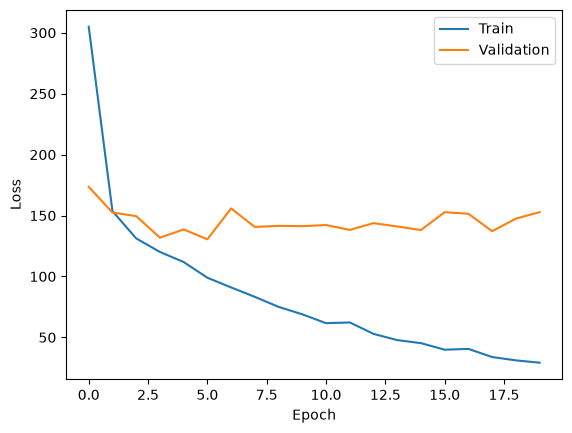

In [ ]:
plt.plot(losses["train"], label="Train")
plt.plot(losses["val"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()